# SHAP — TabPFN interpretation

TabPFN is currently the study's best model (R² 0.863, MAE 0.0145 — beat the frozen DNN). It has no native `feature_importances_` (not a tree), so SHAP is the interpretation route. Uses `KernelExplainer` (model-agnostic, only calls `.predict`) — works with any model, but is more expensive; a smoke test on a small sample took ~7.4 min for the 245 rows with `nsamples="auto"` and 20 background samples.

**Model trained on all 245 animals** (not CV) — interpretation of the final model, same logic as the native importance already seen for XGBoost.

**⚠️ Multicollinearity to watch for when reading the results** (changed after the Sonico→Elvis merge — see `CLAUDE.md`): `numero_eventos_transporte`×`media_proteina_bruta_forragem_pct` r=−0.85 (forage became almost a farm proxy), `proporcao_ciclo_seca`×`temperatura_media_c` r=−0.59, `media_proteina_bruta_forragem_pct`×`proporcao_bos_indicus_pct` r=−0.59. SHAP can split credit between correlated pairs in a non-obvious way — read the importance of these pairs jointly, not in isolation.

## 1. Setup

In [1]:
import sys, os, time
sys.path.append("support_scripts")

from dotenv import load_dotenv
load_dotenv(dotenv_path=".env")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import shap
from tabpfn import TabPFNRegressor
import data_prep as dp

np.random.seed(dp.SEED)

## 2. Data and multicollinearity (diagnostic)

In [2]:
d = dp.get_data()
df, scale_cols, TARGET = d["df"], d["scale_cols"], dp.TARGET
X, y = df[scale_cols], df[TARGET]
print(f"{len(df)} animais | {len(scale_cols)} preditores")

corr = X.corr()
mask = np.triu(np.ones(corr.shape, dtype=bool))
pairs = corr.mask(mask).stack().reset_index()
pairs.columns = ["a", "b", "r"]
pairs["absr"] = pairs.r.abs()
print("pares mais correlacionados:")
pairs.sort_values("absr", ascending=False).head(6)

245 animais | 9 preditores
pares mais correlacionados:


,a,b,r,absr
59,numero_eventos_transporte,media_proteina_bruta_forragem_pct,-0.846788,0.846788
79,proporcao_ciclo_seca,temperatura_media_c,-0.589794,0.589794
47,media_proteina_bruta_forragem_pct,proporcao_bos_indicus_pct,-0.586078,0.586078
49,media_proteina_bruta_forragem_pct,pb_suplemento_pct,-0.499768,0.499768
56,numero_eventos_transporte,proporcao_bos_indicus_pct,0.496284,0.496284
9,dias_permanencia,peso_entrada_kg,-0.483590,0.483590


## 3. Final model (all 245 animals)

In [3]:
model = TabPFNRegressor(random_state=dp.SEED)
t0 = time.time()
model.fit(X.values, y.values)
print(f"fit: {time.time()-t0:.1f}s")

fit: 1.9s


## 4. SHAP values (`KernelExplainer`)

Small background set (20 samples, via `shap.sample`) — trades marginal precision for time, viable for this dataset's N. `nsamples="auto"` is SHAP's default (more precise than a fixed low value).

In [4]:
bg = shap.sample(X, 20, random_state=dp.SEED)
explainer = shap.KernelExplainer(model.predict, bg)

t0 = time.time()
shap_values = explainer.shap_values(X, nsamples="auto")
print(f"shap_values: {time.time()-t0:.1f}s | shape={shap_values.shape}")

np.save("results/shap_values_tabpfn.npy", shap_values)
print("salvo em results/shap_values_tabpfn.npy")

  0%|          | 0/245 [00:00<?, ?it/s]

shap_values: 812.0s | shape=(245, 9)
salvo em results/shap_values_tabpfn.npy


## 5. Global importance (beeswarm + bar chart)

/tmp/ipykernel_103944/3009910650.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


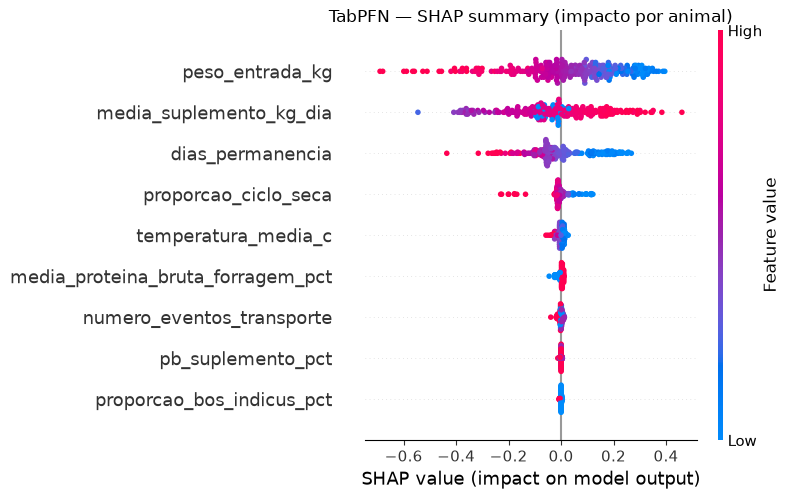

In [5]:
shap.summary_plot(shap_values, X, show=False)
plt.title("TabPFN — SHAP summary (impacto por animal)")
plt.tight_layout(); plt.show()

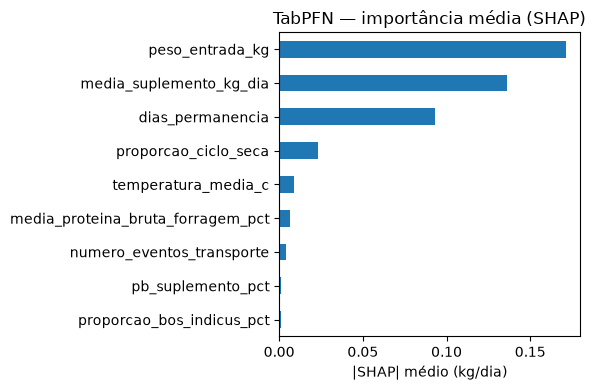

peso_entrada_kg                      0.1712
media_suplemento_kg_dia              0.1358
dias_permanencia                     0.0928
proporcao_ciclo_seca                 0.0230
temperatura_media_c                  0.0090
media_proteina_bruta_forragem_pct    0.0064
numero_eventos_transporte            0.0042
pb_suplemento_pct                    0.0013
proporcao_bos_indicus_pct            0.0012
dtype: float64

In [6]:
imp = pd.Series(np.abs(shap_values).mean(axis=0), index=scale_cols).sort_values()
fig, ax = plt.subplots(figsize=(6, 4))
imp.plot.barh(ax=ax)
ax.set_xlabel("|SHAP| médio (kg/dia)"); ax.set_title("TabPFN — importância média (SHAP)")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4)

## 6. Dependence plots — top 3 features

Shows how each feature's SHAP value varies with its own value (colored by the feature it interacts with most) — helps see the direction of the effect, not just the magnitude.

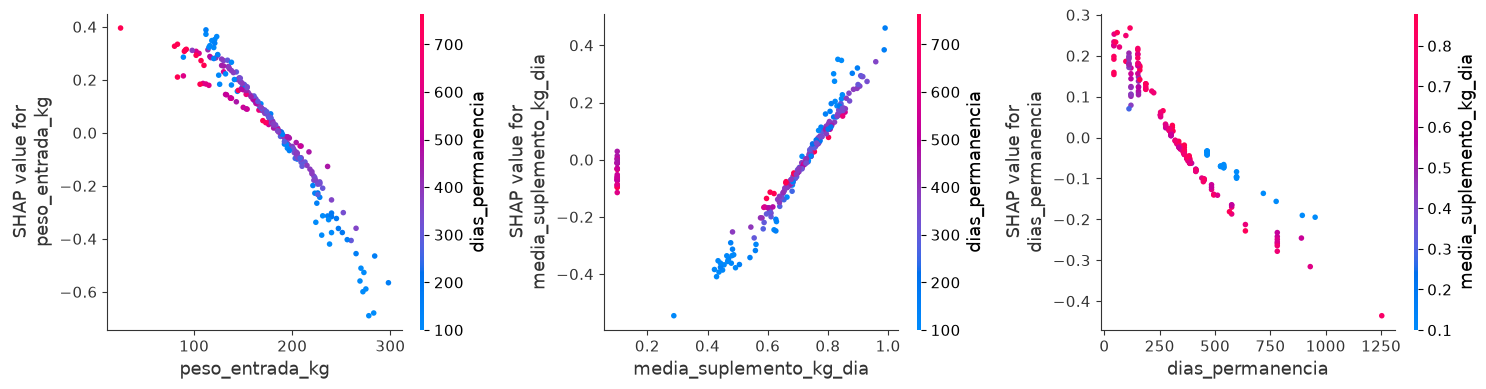

In [7]:
top3 = imp.sort_values(ascending=False).index[:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, top3):
    shap.dependence_plot(feat, shap_values, X, ax=ax, show=False)
plt.tight_layout(); plt.show()

## 7. Notes

- Model trained on all 245 animals (interpretation of the final model, not a CV metric).
- `KernelExplainer` is model-agnostic (only calls `.predict`) — works for any model, TabPFN included, but is more expensive than a native explainer (e.g. XGBoost's `TreeExplainer`).
- **Watch out for the correlated pairs** (cell 2) when interpreting magnitudes — SHAP can split credit between collinear features in a non-obvious way.
- `shap_values` saved to `results/shap_values_tabpfn.npy` (avoids recomputing; array `(245, 9)`, same order as `scale_cols`/`df`).